In [12]:
import dask
import dask.distributed
from dask_util import DaskClient
import numpy as np

In [2]:
client = DaskClient(local_params={"n_workers":1})

In [3]:
client.getNworkers()

1

In [4]:
%load_ext autoreload
%autoreload 2
import SepVector
import __pyDaskVector as DaskVector
import Hypercube

WARNING! DATAPATH not found. The folder /tmp will be used to write binary files


In [208]:

ns = [10, 10]
os = [0,0]
ds = [1,1]
chunks = [1,3]

ax = Hypercube.axis(n=1, o=1, d=1)
hyp = Hypercube.hypercube(ns=ns, ds=ds, os=os)
vec = SepVector.getSepVector(ns=ns, ds=ds, os=os, storage='dataFloat')
vec.rand()

floatVector
Axis 1: n=10	o=0.000000	d=1.000000
Axis 2: n=10	o=0.000000	d=1.000000

In [209]:
# option 1
# creating from scratch
daskVec = DaskVector.DaskVector(client, vecCls=SepVector.floatVector, ns=ns, ds=ds, os=os, chunks=chunks)

[[0 0]
 [0 3]
 [0 6]]
[[10 3]
 [10 3]
 [10 4]]


In [194]:
daskVec.getNdArray()

[array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], dtype=float32),
 array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], dtype=float32),
 array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]], dtype=float32),
 array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], dtype=float32),
 array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], dtype=float32),
 array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]], dtype=float32),
 array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], dtype=float32),
 array([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], dtype=float32),
 array([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]], dtype=float32)]

In [197]:
# option 2
# creating from existing in-memory SepVector
daskVec = DaskVector.DaskVector(client, from_vector=vec, chunks=chunks)

[[0.0 0.0]
 [3.0 0.0]
 [6.0 0.0]
 [0.0 3.0]
 [3.0 3.0]
 [6.0 3.0]
 [0.0 6.0]
 [3.0 6.0]
 [6.0 6.0]]
[[3 3]
 [3 3]
 [4 3]
 [3 3]
 [3 3]
 [4 3]
 [3 4]
 [3 4]
 [4 4]]


In [198]:
daskVec.norm()

2.8481823077396755

In [199]:
vec.norm()

2.848182439804077

In [74]:
daskVec.shape

[(10, 5), (10, 5)]

In [77]:
np.hstack(daskVec.getNdArray()).shape

(10, 10)

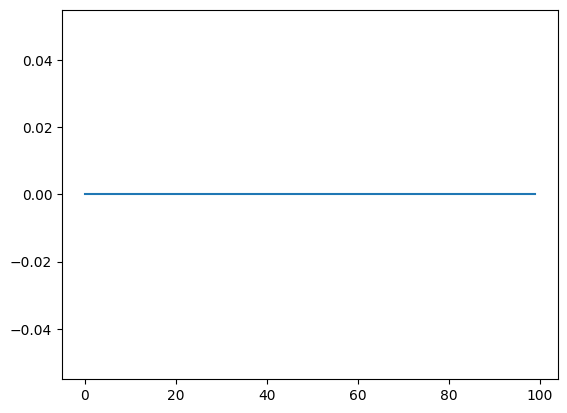

In [78]:
import matplotlib.pyplot as plt

flat1 = vec.getNdArray().flatten()
flat2 = np.hstack(daskVec.getNdArray()).flatten()

plt.plot(flat1-flat2)

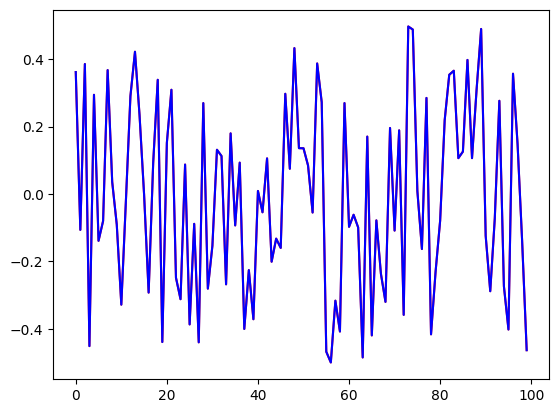

In [79]:
plt.plot(flat1, color='red')
plt.plot(flat2, color='blue')

In [80]:
import dask.array as da



In [113]:
darr = da.empty(daskVec.ns, chunks=((10,),(5,5)))

In [130]:
darr

dask.array<setitem, shape=(10, 10), dtype=float32, chunksize=(10, 10), chunktype=numpy.ndarray>

In [109]:
daskVec.chunks

[(10, 5), (10, 5)]

In [99]:
ls

[[2, 1], [2, 3]]

In [165]:
darr = da.asanyarray(daskVec.getNdArray())

In [166]:
darr

dask.array<array, shape=(2, 10, 5), dtype=float32, chunksize=(2, 10, 5), chunktype=numpy.ndarray>

In [167]:
darr[:] = 2
darr.compute()

array([[[2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.]],

       [[2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.]]], dtype=float32)

In [168]:
vec.getNdArray()

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]], dtype=float32)

In [147]:
darr.

RuntimeError: No visualization engine detected, please install graphviz or ipycytoscape